# SuperKart Sales Revenue Prediction and Deployment

## Problem statement

SuperKart would like to estimate sales revenue for each product-store combination so that regional teams can plan inventory, shelf allocation and store-level targets more consistently. The supplied data describes product characteristics, store attributes and historical product-store revenue. The task is therefore treated as a supervised regression problem, followed by a small deployment layer for single and batch predictions.

The business brief refers to an upcoming-quarter forecast. Since the data has no date or quarter field, the model can only learn the relationship represented by the supplied historical records. The results should be read as product-store revenue estimates rather than a measured seasonal forecast.

**Objective:** build a reproducible regression pipeline that estimates product-store sales revenue and can be used for single and batch predictions.

**Source note:** The course-provided Business Context and template notebook were used to understand the objective, column definitions and marking requirements. The analysis, feature choices, model comparison, interpretations and deployment checks in this notebook were prepared for this submission.

**Working assumptions**

- `Product_Store_Sales_Total` is the target. Its currency and exact reporting period are not supplied, so errors are reported in target units.
- Store age is calculated using 2025. This matches the provided example in which a store established in 2009 has an age of 16 years.
- Product types are grouped into perishables and non-perishables using the rule documented below.
- RMSE is the selection metric because a few large revenue errors can be costly for inventory and regional planning. MAE and R-squared are reported as supporting measures.
- A fixed 80:20 split is used. Model tuning uses only the training portion; the test set is kept aside until final selection.


## Approach note

I split the assignment into two parts. First I checked whether the supplied data could support a useful sales model. I then used the fitted pipeline in a small application so that predictions outside the notebook follow the same preparation steps used during training.

This is the sequence I followed:

1. **Check the data before modelling.** Confirm the record grain, data types, missing values, duplicate keys and category labels. This gives a reliable starting point for the analysis.
2. **Look at the main business relationships.** Compare revenue with price, allocated area, product group and store format. These plots help identify useful patterns and limits; they are not treated as proof of cause and effect.
3. **Prepare a stable feature set.** Standardise the inconsistent sugar label, derive product family and store age, and remove identifiers that would encourage memorisation.
4. **Build two tree-based models.** Random Forest and Gradient Boosting can represent curved relationships and interactions in this retail data. A mean benchmark provides a simple reference point.
5. **Tune using training data only.** Cross-validation selects the model settings. The test set is left untouched until the final choice is made.
6. **Use several checks.** RMSE is the main selection measure, supported by MAE, R-squared, residual plots and errors by store segment.
7. **Reuse the fitted pipeline in deployment.** The saved preprocessing and model are exposed through a Flask API and used by a Streamlit interface for single-record and CSV predictions.

### Choice of tools

- **Python, pandas and NumPy** are used for the data checks and transformations.
- **Seaborn and Matplotlib** are used for the exploratory and diagnostic plots.
- **scikit-learn pipelines** keep encoding and modelling together, which helps the API apply the same steps used in training.
- **Joblib** saves and reloads the fitted scikit-learn pipeline.
- **Flask** supplies small health, single-prediction and batch-prediction endpoints.
- **Streamlit** provides a simple form and CSV upload page without a separate front-end project.
- **GitHub Codespaces** provides a reproducible demonstration environment that can run from the repository.


## 1. Setup

The cell below installs packages only when they are missing. This keeps the notebook convenient in Google Colab without reinstalling libraries on every run.

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy==2.0.2",
    "pandas": "pandas==2.2.2",
    "sklearn": "scikit-learn==1.6.1",
    "matplotlib": "matplotlib==3.10.0",
    "seaborn": "seaborn==0.13.2",
    "joblib": "joblib==1.4.2",
    "flask": "flask==3.1.0",
    "requests": "requests==2.32.4",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Environment is ready.")

Environment is ready.


In [2]:
from io import BytesIO
from pathlib import Path
import importlib.util
import json
import os
import warnings

Path(".matplotlib_cache").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib_cache").resolve()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
REFERENCE_YEAR = 2025

## 2. Load the supplied files

When the files are not already in a local `data` folder, the notebook opens the Colab upload dialog. Upload both `SuperKart.csv` and `Batch_Data_SuperKart.csv` together.

In [3]:
training_path = Path("data/SuperKart.csv")
batch_path = Path("data/Batch_Data_SuperKart.csv")

if not training_path.exists() or not batch_path.exists():
    try:
        from google.colab import files
        print("Upload SuperKart.csv and Batch_Data_SuperKart.csv")
        uploaded = files.upload()
        training_path = Path("SuperKart.csv")
        batch_path = Path("Batch_Data_SuperKart.csv")
    except ImportError as exc:
        raise FileNotFoundError(
            "Place both CSV files in a data folder before running outside Colab."
        ) from exc

data = pd.read_csv(training_path)
batch_data = pd.read_csv(batch_path)
print(f"Training data loaded: {data.shape[0]:,} rows and {data.shape[1]} columns")
print(f"Batch data loaded: {batch_data.shape[0]:,} rows and {batch_data.shape[1]} columns")
display(data.head())

Training data loaded: 8,763 rows and 12 columns
Batch data loaded: 10 rows and 10 columns


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.660,Low Sugar,0.027,Frozen Foods,117.080,OUT004,2009,Medium,Tier 2,Supermarket Type2,"2,842.400"
1,FD7839,16.540,Low Sugar,0.144,Dairy,171.430,OUT003,1999,Medium,Tier 1,Departmental Store,"4,830.020"
2,FD5075,14.280,Regular,0.031,Canned,162.080,OUT001,1987,High,Tier 2,Supermarket Type1,"4,130.160"
3,FD8233,12.100,Low Sugar,0.112,Baking Goods,186.310,OUT001,1987,High,Tier 2,Supermarket Type1,"4,132.180"
4,NC1180,9.570,No Sugar,0.010,Health and Hygiene,123.670,OUT002,1998,Small,Tier 3,Food Mart,"2,279.360"


## 3. Data overview

The checks answer five basic questions before modelling: What is the data grain? Are the types appropriate? Are values missing? Are any rows duplicated? Do the ranges and category labels look plausible?

In [4]:
overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique_values": data.nunique(),
})
display(overview)
print(f"Exact duplicate rows: {data.duplicated().sum():,}")
print(f"Duplicate Product_Id + Store_Id pairs: {data.duplicated(['Product_Id', 'Store_Id']).sum():,}")
display(data.describe(include="all").T)

,dtype,missing,unique_values
Product_Id,object,0,8763
Product_Weight,float64,0,1113
Product_Sugar_Content,object,0,4
Product_Allocated_Area,float64,0,228
Product_Type,object,0,16
Product_MRP,float64,0,6100
Store_Id,object,0,4
Store_Establishment_Year,int64,0,4
Store_Size,object,0,3
Store_Location_City_Type,object,0,3


Exact duplicate rows: 0
Duplicate Product_Id + Store_Id pairs: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,"8,763.000",NaN,NaN,NaN,12.654,2.217,4.000,11.150,12.660,14.180,22.000
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,"8,763.000",NaN,NaN,NaN,0.069,0.048,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,"8,763.000",NaN,NaN,NaN,147.033,30.694,31.000,126.160,146.740,167.585,266.000
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,"8,763.000",NaN,NaN,NaN,"2,002.033",8.388,"1,987.000","1,998.000","2,009.000","2,009.000","2,009.000"
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
categorical_columns = data.select_dtypes(include="object").columns
for column in categorical_columns:
    print(f"\n{column}: {data[column].nunique()} unique values")
    display(data[column].value_counts(dropna=False).to_frame("count"))


Product_Id: 8763 unique values


,count
Product_Id,
FD306,1
FD6114,1
FD7839,1
FD5075,1
FD8233,1
...,...
FD1387,1
FD1231,1
FD5276,1



Product_Sugar_Content: 4 unique values


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108



Product_Type: 16 unique values


...

,count
Store_Size,
Medium,6025
High,1586
Small,1152



Store_Location_City_Type: 3 unique values


,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152



Store_Type: 4 unique values


,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


**Overview observations**

- The training file contains 8,763 product-store records and 12 columns. There are no missing values, exact duplicates, or duplicate product-store keys.
- Five fields are numeric; the remaining fields are identifiers or categories.
- `Product_Sugar_Content` has both `Regular` and the abbreviated label `reg`. These describe the same category and should be standardized.
- `Product_Id` is unique in this file, so the complete identifier would encourage memorisation rather than a reusable pattern. Its two-letter prefix is more suitable as a broad product-family feature.
- Only four stores are represented. Each store also has one fixed size, location tier and store type, which limits how confidently the model can generalise to a new store format.

## 4. Exploratory data analysis

### 4.1 Univariate analysis

The numerical plots show distribution, skew and unusual values. Category charts are limited to fields that help describe the business mix.

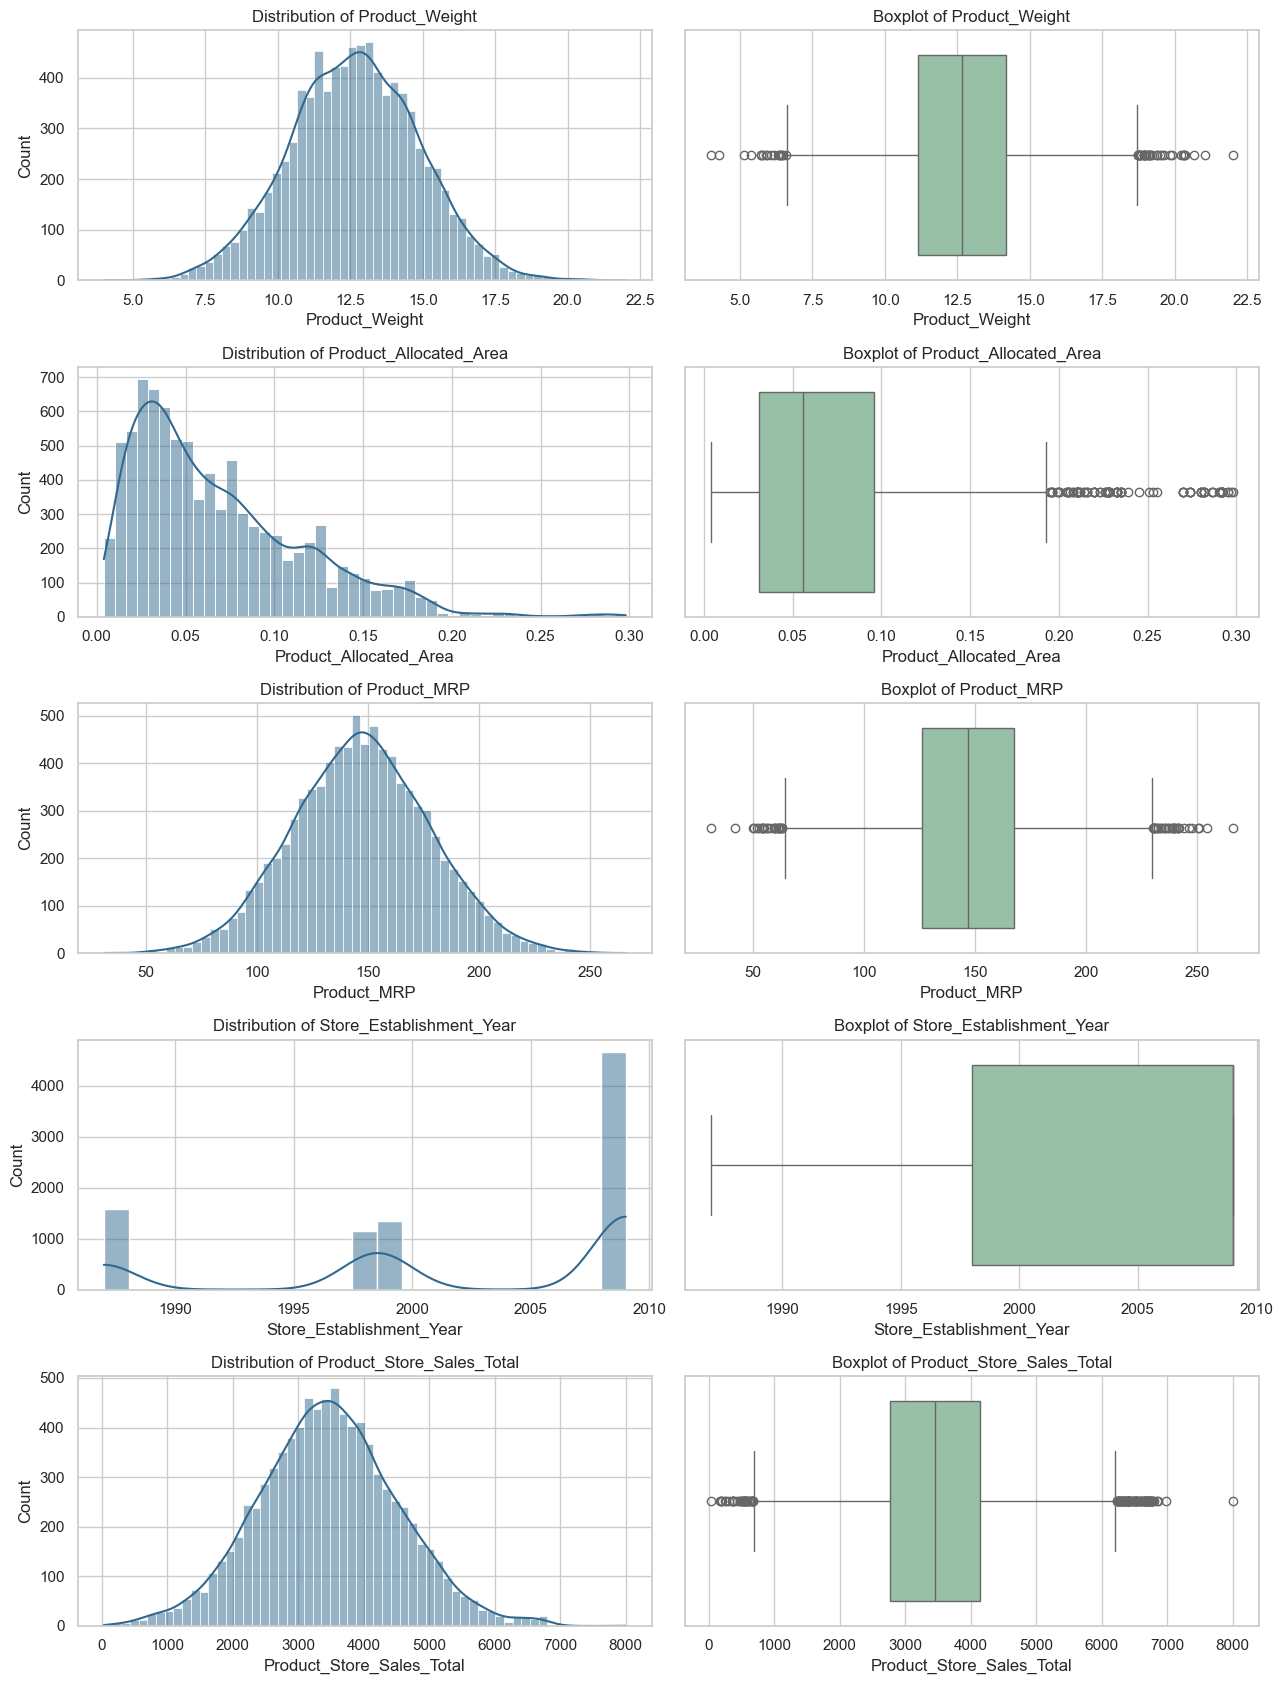

In [6]:
numeric_columns = [
    "Product_Weight", "Product_Allocated_Area", "Product_MRP",
    "Store_Establishment_Year", "Product_Store_Sales_Total"
]

fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(13, 17))
for row, column in enumerate(numeric_columns):
    sns.histplot(data=data, x=column, kde=True, ax=axes[row, 0], color="#31688e")
    sns.boxplot(data=data, x=column, ax=axes[row, 1], color="#90c7a6")
    axes[row, 0].set_title(f"Distribution of {column}")
    axes[row, 1].set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

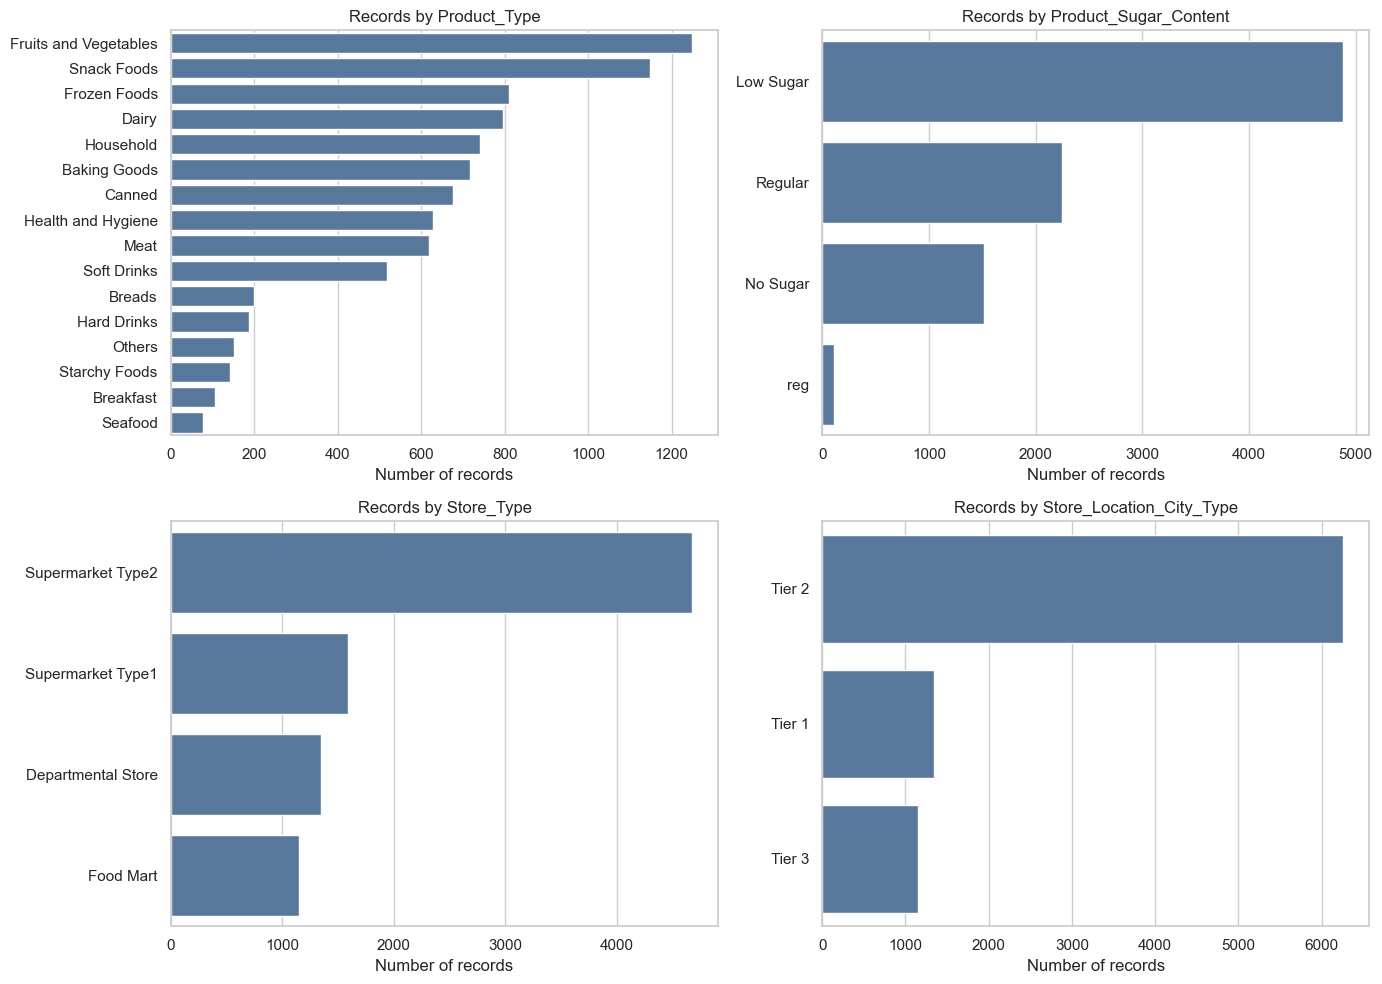

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
category_plots = ["Product_Type", "Product_Sugar_Content", "Store_Type", "Store_Location_City_Type"]
for ax, column in zip(axes.flat, category_plots):
    order = data[column].value_counts().index
    sns.countplot(data=data, y=column, order=order, ax=ax, color="#4c78a8")
    ax.set_title(f"Records by {column}")
    ax.set_xlabel("Number of records")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [8]:
outlier_summary = []
for column in ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]:
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((data[column] < lower) | (data[column] > upper)).sum()
    outlier_summary.append([column, lower, upper, int(count), count / len(data)])

outliers = pd.DataFrame(
    outlier_summary,
    columns=["feature", "lower_fence", "upper_fence", "flagged_rows", "share"]
)
display(outliers.style.format({"lower_fence": "{:.3f}", "upper_fence": "{:.3f}", "share": "{:.2%}"}))

,feature,lower_fence,upper_fence,flagged_rows,share
0,Product_Weight,6.605,18.725,54,0.62%
1,Product_Allocated_Area,-0.067,0.194,104,1.19%
2,Product_MRP,64.022,229.723,57,0.65%
3,Product_Store_Sales_Total,686.540,6220.340,119,1.36%


**Univariate observations**

- Revenue is centred around 3,464 target units and has a moderate upper tail. The highest values are uncommon but still plausible sales outcomes.
- Allocated area is right-skewed. Large display allocations may be commercially meaningful rather than data errors.
- The IQR rule flags a small share of rows. No impossible values or recording errors are evident, so the records are retained. Tree-based models also reduce the need to cap predictor values mechanically.
- The store mix is uneven: Supermarket Type2 contributes more than half the records. Performance should therefore be checked by store type after final model selection.

### 4.2 Bivariate analysis

The next plots examine how revenue changes with price, allocated area, product type and store type. Medians are shown for categories because they are less influenced by a few large values.

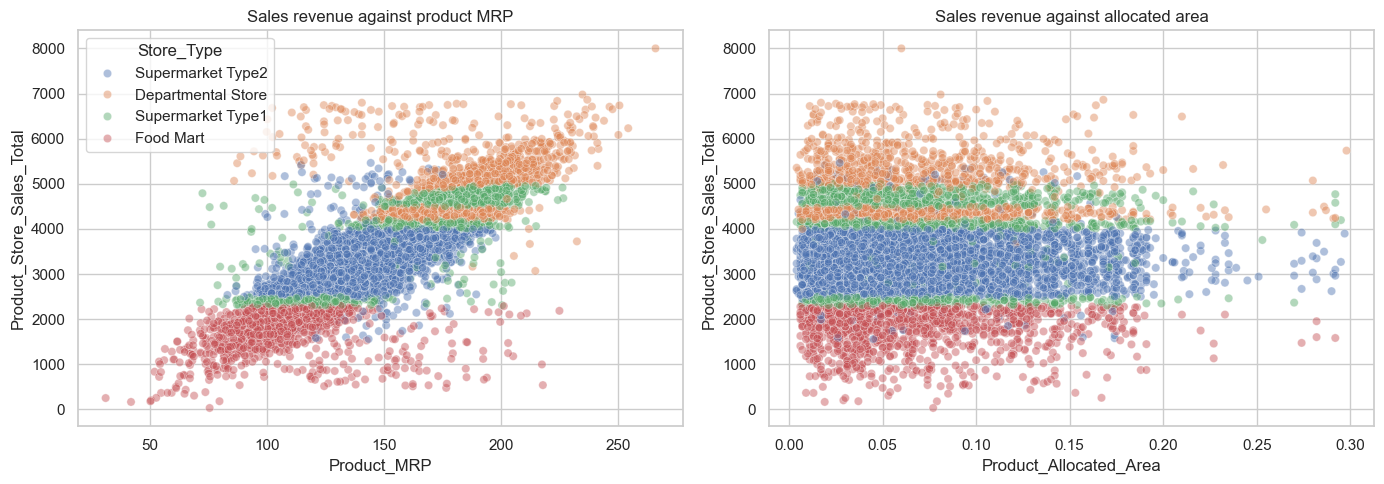

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=data, x="Product_MRP", y="Product_Store_Sales_Total",
    hue="Store_Type", alpha=0.45, ax=axes[0]
)
axes[0].set_title("Sales revenue against product MRP")
sns.scatterplot(
    data=data, x="Product_Allocated_Area", y="Product_Store_Sales_Total",
    hue="Store_Type", alpha=0.45, ax=axes[1], legend=False
)
axes[1].set_title("Sales revenue against allocated area")
plt.tight_layout()
plt.show()

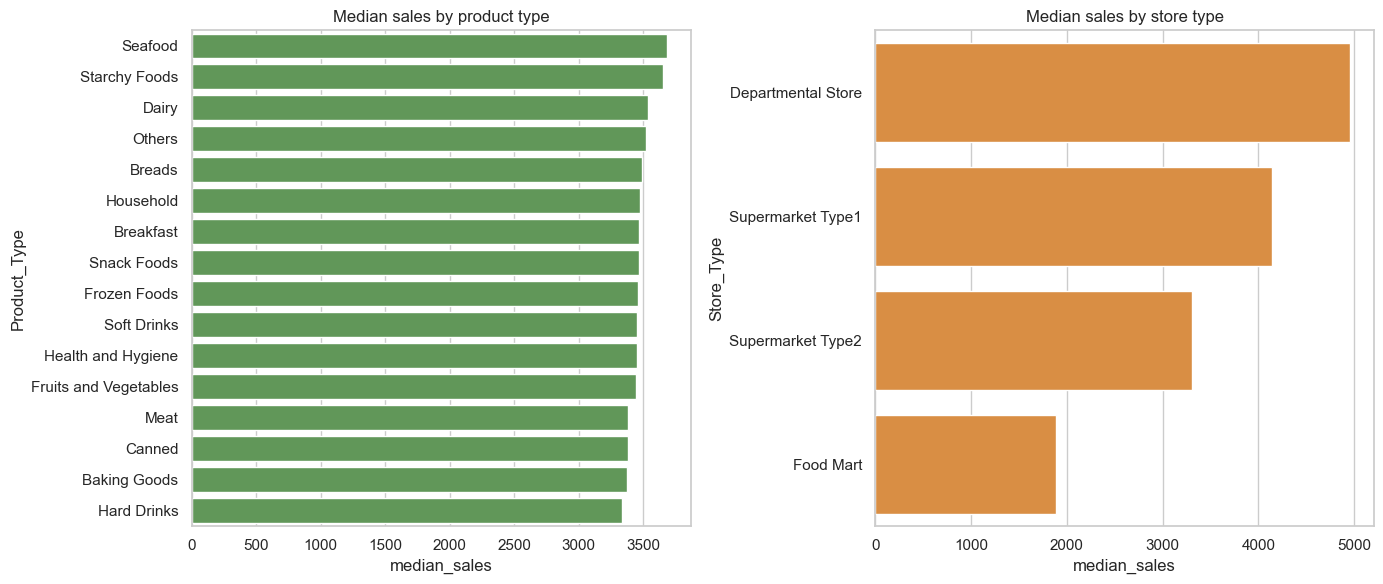

,Product_Type,median_sales,records
12,Seafood,"3,682.465",76
15,Starchy Foods,"3,655.170",141
4,Dairy,"3,536.275",796
11,Others,"3,518.550",151
1,Breads,"3,486.950",200
9,Household,"3,472.355",740
2,Breakfast,"3,468.500",106
13,Snack Foods,"3,464.610",1149
5,Frozen Foods,"3,458.090",811
14,Soft Drinks,"3,453.340",519


,Store_Type,median_sales,records
0,Departmental Store,"4,958.290",1349
2,Supermarket Type1,"4,139.645",1586
3,Supermarket Type2,"3,304.180",4676
1,Food Mart,"1,889.495",1152


In [10]:
product_summary = (
    data.groupby("Product_Type", as_index=False)
    .agg(median_sales=("Product_Store_Sales_Total", "median"), records=("Product_Id", "size"))
    .sort_values("median_sales", ascending=False)
)
store_summary = (
    data.groupby("Store_Type", as_index=False)
    .agg(median_sales=("Product_Store_Sales_Total", "median"), records=("Product_Id", "size"))
    .sort_values("median_sales", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=product_summary, y="Product_Type", x="median_sales", ax=axes[0], color="#59a14f")
axes[0].set_title("Median sales by product type")
sns.barplot(data=store_summary, y="Store_Type", x="median_sales", ax=axes[1], color="#f28e2b")
axes[1].set_title("Median sales by store type")
plt.tight_layout()
plt.show()
display(product_summary)
display(store_summary)

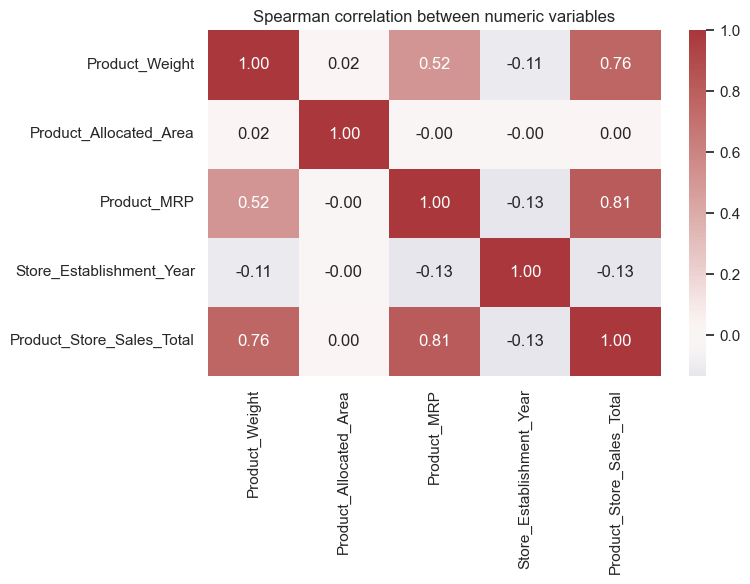

In [11]:
numeric_corr = data[numeric_columns].corr(method="spearman")
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlation between numeric variables")
plt.tight_layout()
plt.show()

**Bivariate observations**

- MRP has the clearest positive association with revenue. Higher-priced products tend to generate higher recorded revenue, although the spread shows that price alone is not sufficient.
- Allocated display area also shows a positive association with sales. This is useful for prediction, but it should not be interpreted as proof that increasing display area causes the same increase in sales.
- Store formats have visibly different revenue distributions. Because each observed store maps to a fixed format, the difference may contain both store-specific and format effects.
- Product-type medians vary less dramatically than store-format medians. Product grouping may still help the model capture broad handling and demand differences.

## 5. Data preparation and feature engineering

The production input should be understandable and stable. Three features are created:

- `Product_Id_char`: the two-letter product-family prefix (`FD`, `DR`, or `NC`).
- `Store_Age_Years`: 2025 minus establishment year.
- `Product_Type_Category`: a documented perishability grouping. Frozen and packaged products are treated as non-perishable for this broad operational grouping.

Full product and store identifiers are removed. The detailed product type is also replaced by the broader category so the training schema matches the supplied batch file.

In [12]:
perishables = {
    "Breads", "Breakfast", "Dairy", "Fruits and Vegetables", "Meat", "Seafood"
}

def engineer_features(frame):
    result = frame.copy()
    result["Product_Sugar_Content"] = result["Product_Sugar_Content"].replace({"reg": "Regular"})
    result["Product_Id_char"] = result["Product_Id"].str[:2]
    result["Store_Age_Years"] = REFERENCE_YEAR - result["Store_Establishment_Year"]
    result["Product_Type_Category"] = np.where(
        result["Product_Type"].isin(perishables), "Perishables", "Non Perishables"
    )
    return result

model_data = engineer_features(data)
target = "Product_Store_Sales_Total"
feature_columns = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
    "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
    "Store_Age_Years", "Product_Type_Category"
]
X = model_data[feature_columns]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
display(X_train.head())

Training rows: 7,010
Test rows: 1,753


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
5967,13.640,No Sugar,0.071,157.100,Medium,Tier 2,Supermarket Type2,NC,16,Non Perishables
8270,10.030,Low Sugar,0.016,126.660,High,Tier 2,Supermarket Type1,FD,38,Non Perishables
100,12.260,Low Sugar,0.140,138.270,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
3410,10.280,Low Sugar,0.143,147.440,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
1790,16.380,Low Sugar,0.082,205.160,Medium,Tier 1,Departmental Store,FD,26,Non Perishables


In [13]:
print("Feature schema check against the supplied batch file")
print("Training features only:", sorted(set(feature_columns) - set(batch_data.columns)))
print("Batch features only:", sorted(set(batch_data.columns) - set(feature_columns)))

category_checks = []
for column in X_train.select_dtypes(include="object").columns:
    unseen = sorted(set(batch_data[column].dropna()) - set(X_train[column].dropna()))
    category_checks.append([column, unseen])
display(pd.DataFrame(category_checks, columns=["feature", "unseen_batch_categories"]))

Feature schema check against the supplied batch file
Training features only: []
Batch features only: []


,feature,unseen_batch_categories
0,Product_Sugar_Content,[]
1,Store_Size,[]
2,Store_Location_City_Type,[]
3,Store_Type,[Supermarket Type3]
4,Product_Id_char,[]
5,Product_Type_Category,[]


The batch schema matches the ten training features. `Supermarket Type3` is new at inference time. `OneHotEncoder(handle_unknown="ignore")` prevents a system failure, but predictions for that category are extrapolations and should be monitored before operational use.

In [14]:
numeric_features = X_train.select_dtypes(exclude="object").columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']
Categorical features: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']


## 6. Model building

Random Forest and Gradient Boosting are both permitted by the rubric and suit mixed, non-linear retail data. Every model is built as a pipeline, so encoding is learned within each training fold and applied identically during deployment.

A mean-prediction benchmark is included to show whether the models add useful predictive value. It is not treated as one of the two required machine-learning models.

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

initial_rows = []
fitted_initial = {}
baseline_rmse = np.sqrt(np.mean((y_train - y_train.mean()) ** 2))
baseline_mae = np.mean(np.abs(y_train - y_train.mean()))
initial_rows.append(["Mean benchmark", baseline_rmse, baseline_mae, 0.0, np.nan])

for name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    initial_rows.append([
        name,
        -scores["test_rmse"].mean(),
        -scores["test_mae"].mean(),
        scores["test_r2"].mean(),
        scores["test_rmse"].std(),
    ])
    fitted_initial[name] = pipeline.fit(X_train, y_train)

initial_results = pd.DataFrame(
    initial_rows,
    columns=["model", "cv_rmse", "cv_mae", "cv_r2", "rmse_std"]
).sort_values("cv_rmse")
display(initial_results.style.format({
    "cv_rmse": "{:,.2f}", "cv_mae": "{:,.2f}", "cv_r2": "{:.3f}", "rmse_std": "{:,.2f}"
}))

,model,cv_rmse,cv_mae,cv_r2,rmse_std
1,Random Forest,282.45,105.88,0.929,28.94
2,Gradient Boosting,315.81,147.02,0.911,28.25
0,Mean benchmark,"1,064.91",839.89,0.000,nan


In [16]:
best_initial = initial_results.iloc[0]
display(Markdown(
    f"The best initial model is **{best_initial['model']}**, with a five-fold validation "
    f"RMSE of **{best_initial['cv_rmse']:,.2f}** and R-squared of "
    f"**{best_initial['cv_r2']:.3f}**. Both ensemble models are compared again after tuning."
))

The best initial model is **Random Forest**, with a five-fold validation RMSE of **282.45** and R-squared of **0.929**. Both ensemble models are compared again after tuning.

## 7. Hyperparameter tuning

The grids vary tree depth, learning behaviour and regularisation. Five-fold cross-validation would give a slightly more stable estimate, but three folds are used here to keep the notebook practical in a free Colab runtime. The same folds and primary metric are used for both candidates.

In [17]:
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "Tuned Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        {
            "model__n_estimators": [150, 300],
            "model__max_depth": [None, 12],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": [0.8],
        },
    ),
    "Tuned Gradient Boosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 180],
            "model__learning_rate": [0.04, 0.08],
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [10],
            "model__subsample": [0.9],
        },
    ),
}

tuned_models = {}
tuning_rows = []
for name, (estimator, parameters) in search_spaces.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    search = GridSearchCV(
        pipeline,
        param_grid=parameters,
        scoring="neg_root_mean_squared_error",
        cv=tuning_cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_rows.append([name, -search.best_score_, search.best_params_])

tuning_results = pd.DataFrame(tuning_rows, columns=["model", "tuning_cv_rmse", "best_parameters"])
display(tuning_results.style.format({"tuning_cv_rmse": "{:,.2f}"}))

,model,tuning_cv_rmse,best_parameters
0,Tuned Random Forest,285.23,"{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}"
1,Tuned Gradient Boosting,311.82,"{'model__learning_rate': 0.08, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 180, 'model__subsample': 0.9}"


## 8. Performance comparison and final selection

To compare all four fitted candidates on equal terms, the tuned estimators are evaluated with the same five-fold split used for the initial models. Selection is based on validation RMSE. The held-out test set remains untouched during this comparison.

In [18]:
comparison_rows = []
all_candidates = {**fitted_initial, **tuned_models}

for name, pipeline in all_candidates.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    comparison_rows.append([
        name,
        -scores["test_rmse"].mean(),
        -scores["test_mae"].mean(),
        scores["test_r2"].mean(),
        scores["test_rmse"].std(),
    ])

comparison = pd.DataFrame(
    comparison_rows,
    columns=["model", "cv_rmse", "cv_mae", "cv_r2", "rmse_std"]
).sort_values("cv_rmse").reset_index(drop=True)
display(comparison.style.format({
    "cv_rmse": "{:,.2f}", "cv_mae": "{:,.2f}", "cv_r2": "{:.3f}", "rmse_std": "{:,.2f}"
}))

selected_name = comparison.loc[0, "model"]
final_model = all_candidates[selected_name].fit(X_train, y_train)
display(Markdown(
    f"**{selected_name}** is selected because it has the lowest cross-validated RMSE "
    f"({comparison.loc[0, 'cv_rmse']:,.2f}). Its fold-to-fold RMSE standard deviation is "
    f"{comparison.loc[0, 'rmse_std']:,.2f}, which provides context for the stability of that estimate."
))

,model,cv_rmse,cv_mae,cv_r2,rmse_std
0,Tuned Random Forest,280.94,107.20,0.930,28.96
1,Random Forest,282.45,105.88,0.929,28.94
2,Tuned Gradient Boosting,310.84,141.48,0.914,31.03
3,Gradient Boosting,315.81,147.02,0.911,28.25


**Tuned Random Forest** is selected because it has the lowest cross-validated RMSE (280.94). Its fold-to-fold RMSE standard deviation is 28.96, which provides context for the stability of that estimate.

In [19]:
test_predictions = final_model.predict(X_test)
test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)

test_metrics = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R-squared"],
    "test_value": [test_rmse, test_mae, test_r2],
})
display(test_metrics.style.format({"test_value": "{:,.3f}"}))
display(Markdown(
    f"On the untouched test set, the selected pipeline achieves RMSE **{test_rmse:,.2f}**, "
    f"MAE **{test_mae:,.2f}**, and R-squared **{test_r2:.3f}**. MAE indicates the typical "
    "absolute miss, while RMSE is higher because it gives more weight to the largest errors."
))

,metric,test_value
0,RMSE,277.310
1,MAE,106.073
2,R-squared,0.933


On the untouched test set, the selected pipeline achieves RMSE **277.31**, MAE **106.07**, and R-squared **0.933**. MAE indicates the typical absolute miss, while RMSE is higher because it gives more weight to the largest errors.

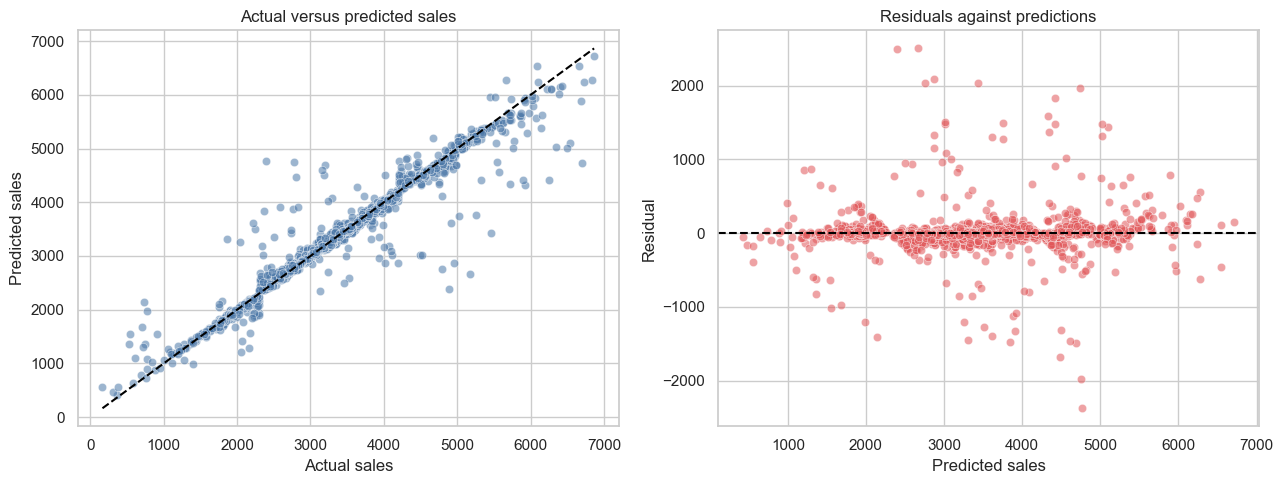

In [20]:
residuals = y_test.to_numpy() - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=y_test, y=test_predictions, alpha=0.55, ax=axes[0], color="#4c78a8")
limits = [min(y_test.min(), test_predictions.min()), max(y_test.max(), test_predictions.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(xlabel="Actual sales", ylabel="Predicted sales", title="Actual versus predicted sales")
sns.scatterplot(x=test_predictions, y=residuals, alpha=0.55, ax=axes[1], color="#e15759")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(xlabel="Predicted sales", ylabel="Residual", title="Residuals against predictions")
plt.tight_layout()
plt.show()

In [21]:
error_review = X_test[["Store_Type", "Product_Type_Category"]].copy()
error_review["absolute_error"] = np.abs(residuals)
segment_error = (
    error_review.groupby("Store_Type", as_index=False)
    .agg(records=("absolute_error", "size"), mae=("absolute_error", "mean"))
    .sort_values("mae", ascending=False)
)
display(segment_error.style.format({"mae": "{:,.2f}"}))

,Store_Type,records,mae
0,Departmental Store,269,171.08
2,Supermarket Type1,327,136.93
1,Food Mart,248,105.04
3,Supermarket Type2,909,76.02


The segment table is a diagnostic rather than proof of store-format causation. With only four stores and a fixed mapping between store and format, store-level history would be needed before changing regional policy solely from these differences.

## 9. Serialize and reload the complete pipeline

Saving the full pipeline is important: the deployed application must reuse the same feature order and one-hot encoding learned during training.

In [22]:
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
model_path = artifact_dir / "superkart_model.joblib"
joblib.dump(final_model, model_path)

reloaded_model = joblib.load(model_path)
reloaded_predictions = reloaded_model.predict(X_test)
max_difference = np.max(np.abs(test_predictions - reloaded_predictions))
print(f"Saved model: {model_path}")
print(f"Maximum prediction difference after reload: {max_difference:.12f}")
assert np.allclose(test_predictions, reloaded_predictions)

Saved model: artifacts\superkart_model.joblib
Maximum prediction difference after reload: 0.000000000000


## 10. Create the Flask backend

The backend provides a health endpoint, one-record prediction, and CSV batch prediction. It rejects missing fields and non-tabular batch uploads with clear client errors.

In [23]:
backend_dir = Path("deployment/backend")
backend_dir.mkdir(parents=True, exist_ok=True)

backend_code = r'''from io import StringIO
import os
from pathlib import Path

import joblib
import pandas as pd
from flask import Flask, jsonify, request

app = Flask(__name__)
DEFAULT_MODEL = Path(__file__).resolve().parents[2] / "artifacts" / "superkart_model.joblib"
MODEL_PATH = Path(os.getenv("MODEL_PATH", DEFAULT_MODEL))
model = joblib.load(MODEL_PATH)

FEATURES = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
    "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
    "Store_Age_Years", "Product_Type_Category"
]

def validate_columns(frame):
    missing = [column for column in FEATURES if column not in frame.columns]
    if missing:
        raise ValueError("Missing required fields: " + ", ".join(missing))
    return frame[FEATURES]

@app.get("/health")
def health():
    return jsonify({"status": "ok", "model": MODEL_PATH.name})

@app.post("/v1/predict")
def predict_one():
    try:
        payload = request.get_json(force=True)
        frame = validate_columns(pd.DataFrame([payload]))
        prediction = float(model.predict(frame)[0])
        return jsonify({"predicted_sales": round(prediction, 2)})
    except (ValueError, TypeError) as exc:
        return jsonify({"error": str(exc)}), 400

@app.post("/v1/predictbatch")
def predict_batch():
    try:
        if "file" not in request.files:
            raise ValueError("Upload a CSV file using the 'file' field.")
        text = request.files["file"].read().decode("utf-8")
        frame = validate_columns(pd.read_csv(StringIO(text)))
        predictions = model.predict(frame)
        return jsonify({"predictions": [round(float(value), 2) for value in predictions]})
    except (ValueError, UnicodeDecodeError, pd.errors.ParserError) as exc:
        return jsonify({"error": str(exc)}), 400

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=7860)
'''

(backend_dir / "app.py").write_text(backend_code, encoding="utf-8")
(backend_dir / "requirements.txt").write_text(
    "Flask==3.1.0\njoblib==1.4.2\npandas==2.2.2\nscikit-learn==1.6.1\ngunicorn==23.0.0\n",
    encoding="utf-8",
)
(backend_dir / "Dockerfile").write_text(
    "FROM python:3.11-slim\nWORKDIR /app\nCOPY requirements.txt .\n"
    "RUN pip install --no-cache-dir -r requirements.txt\nCOPY app.py .\n"
    "COPY superkart_model.joblib .\nENV MODEL_PATH=/app/superkart_model.joblib\n"
    "EXPOSE 7860\nCMD [\"gunicorn\", \"--bind\", \"0.0.0.0:7860\", \"app:app\"]\n",
    encoding="utf-8",
)
print("Backend files created:", [path.name for path in backend_dir.iterdir()])

Backend files created: ['app.py', 'Dockerfile', 'requirements.txt', 'superkart_model.joblib', '__pycache__']


In [24]:
# Copy the trained model into the backend folder so the Docker image is self-contained.
import shutil
shutil.copy2(model_path, backend_dir / model_path.name)

os.environ["MODEL_PATH"] = str(model_path.resolve())
spec = importlib.util.spec_from_file_location("superkart_backend", backend_dir / "app.py")
backend_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(backend_module)
client = backend_module.app.test_client()

sample_payload = {
    "Product_Weight": 12.66,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.027,
    "Product_MRP": 117.08,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type2",
    "Product_Id_char": "FD",
    "Store_Age_Years": 16,
    "Product_Type_Category": "Non Perishables",
}
online_response = client.post("/v1/predict", json=sample_payload)
invalid_response = client.post("/v1/predict", json={"Product_Weight": 12.66})
print("Health:", client.get("/health").get_json())
print("Valid request:", online_response.status_code, online_response.get_json())
print("Invalid request:", invalid_response.status_code, invalid_response.get_json())
assert online_response.status_code == 200
assert invalid_response.status_code == 400

Health: {'model': 'superkart_model.joblib', 'status': 'ok'}
Valid request: 200 {'predicted_sales': 2934.75}
Invalid request: 400 {'error': 'Missing required fields: Product_Sugar_Content, Product_Allocated_Area, Product_MRP, Store_Size, Store_Location_City_Type, Store_Type, Product_Id_char, Store_Age_Years, Product_Type_Category'}


## 11. Create the Streamlit frontend

The frontend supports a single prediction form and CSV batch upload. Its backend address comes from an environment variable, so the same code works locally and after deployment.

In [25]:
frontend_dir = Path("deployment/frontend")
frontend_dir.mkdir(parents=True, exist_ok=True)

frontend_code = r'''import os
import pandas as pd
import requests
import streamlit as st

st.set_page_config(page_title="SuperKart Sales Predictor", page_icon="🛒", layout="centered")
API_URL = os.getenv("API_URL", "http://localhost:7860").rstrip("/")

st.title("SuperKart Sales Revenue Predictor")
st.caption("Estimate revenue for one product-store record or upload a batch CSV.")

tab_single, tab_batch = st.tabs(["Single prediction", "Batch prediction"])

with tab_single:
    with st.form("single_prediction"):
        product_weight = st.number_input("Product weight", min_value=0.0, value=12.66)
        sugar = st.selectbox("Sugar content", ["Low Sugar", "Regular", "No Sugar"])
        area = st.number_input("Allocated area ratio", min_value=0.0, max_value=1.0, value=0.027, format="%.3f")
        mrp = st.number_input("Product MRP", min_value=0.0, value=117.08)
        size = st.selectbox("Store size", ["Small", "Medium", "High"])
        city = st.selectbox("City tier", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox(
            "Store type", ["Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store", "Food Mart"]
        )
        prefix = st.selectbox("Product family", ["FD", "DR", "NC"])
        age = st.number_input("Store age in years", min_value=0, value=16)
        category = st.selectbox("Product type category", ["Perishables", "Non Perishables"])
        submitted = st.form_submit_button("Predict sales")

    if submitted:
        payload = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": sugar,
            "Product_Allocated_Area": area,
            "Product_MRP": mrp,
            "Store_Size": size,
            "Store_Location_City_Type": city,
            "Store_Type": store_type,
            "Product_Id_char": prefix,
            "Store_Age_Years": age,
            "Product_Type_Category": category,
        }
        response = requests.post(f"{API_URL}/v1/predict", json=payload, timeout=30)
        if response.ok:
            st.metric("Predicted sales revenue", f"{response.json()['predicted_sales']:,.2f}")
        else:
            st.error(response.json().get("error", "Prediction request failed."))

with tab_batch:
    upload = st.file_uploader("Upload a CSV with the ten model features", type="csv")
    if upload is not None:
        frame = pd.read_csv(upload)
        st.dataframe(frame.head(), use_container_width=True)
        if st.button("Run batch prediction"):
            files = {"file": (upload.name, frame.to_csv(index=False).encode("utf-8"), "text/csv")}
            response = requests.post(f"{API_URL}/v1/predictbatch", files=files, timeout=60)
            if response.ok:
                frame["Predicted_Sales"] = response.json()["predictions"]
                st.dataframe(frame, use_container_width=True)
                st.download_button(
                    "Download predictions", frame.to_csv(index=False),
                    file_name="superkart_predictions.csv", mime="text/csv"
                )
            else:
                st.error(response.json().get("error", "Batch request failed."))
'''

(frontend_dir / "app.py").write_text(frontend_code, encoding="utf-8")
(frontend_dir / "requirements.txt").write_text(
    "streamlit==1.42.0\npandas==2.2.2\nrequests==2.32.4\n",
    encoding="utf-8",
)
(frontend_dir / "Dockerfile").write_text(
    "FROM python:3.11-slim\nWORKDIR /app\nCOPY requirements.txt .\n"
    "RUN pip install --no-cache-dir -r requirements.txt\nCOPY app.py .\n"
    "EXPOSE 7860\nCMD [\"streamlit\", \"run\", \"app.py\", \"--server.address=0.0.0.0\", \"--server.port=7860\"]\n",
    encoding="utf-8",
)
compile(backend_code, "backend/app.py", "exec")
compile(frontend_code, "frontend/app.py", "exec")
print("Frontend files created:", [path.name for path in frontend_dir.iterdir()])
print("Both application files pass Python syntax checking.")

Frontend files created: ['app.py', 'Dockerfile', 'requirements.txt']
Both application files pass Python syntax checking.


## 12. Online and batch inference tests

These tests call the Flask application in memory, which verifies request handling without opening a network port. The public deployment URL can be substituted later without changing the payload format.

In [26]:
batch_buffer = BytesIO(batch_data.to_csv(index=False).encode("utf-8"))
batch_response = client.post(
    "/v1/predictbatch",
    data={"file": (batch_buffer, "Batch_Data_SuperKart.csv")},
    content_type="multipart/form-data",
)
batch_predictions = batch_response.get_json()["predictions"]
batch_results = batch_data.copy()
batch_results["Predicted_Sales"] = batch_predictions
print("Batch response status:", batch_response.status_code)
print("Prediction count:", len(batch_predictions))
display(batch_results)
assert batch_response.status_code == 200
assert len(batch_predictions) == len(batch_data)

Batch response status: 200
Prediction count: 10


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category,Predicted_Sales
0,12.660,Low Sugar,0.027,117.080,Small,Tier 1,Supermarket Type1,FD,16,Perishables,"3,820.480"
1,8.200,Regular,0.045,85.500,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables,"2,858.720"
2,15.400,No Sugar,0.012,210.750,High,Tier 3,Departmental Store,NC,8,Non Perishables,"3,940.190"
3,5.750,Regular,0.060,55.200,Small,Tier 1,Food Mart,FD,30,Perishables,"1,894.060"
4,19.300,Low Sugar,0.033,145.600,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables,"4,058.430"
5,10.000,No Sugar,0.050,92.400,High,Tier 1,Supermarket Type1,NC,5,Non Perishables,"4,772.300"
6,7.850,Regular,0.018,178.900,Small,Tier 3,Supermarket Type2,FD,19,Perishables,"2,386.010"
7,14.100,Low Sugar,0.041,63.250,Medium,Tier 2,Food Mart,DR,27,Perishables,"2,383.030"
8,3.500,No Sugar,0.009,250.000,High,Tier 1,Departmental Store,NC,10,Non Perishables,"4,675.950"
9,11.250,Regular,0.055,130.450,Small,Tier 3,Supermarket Type3,FD,14,Perishables,"2,247.200"


In [27]:
local_batch_predictions = reloaded_model.predict(batch_data[feature_columns])
api_batch_predictions = np.array(batch_predictions)
api_rounding_difference = np.max(np.abs(local_batch_predictions - api_batch_predictions))
print(f"Maximum local/API difference after two-decimal API rounding: {api_rounding_difference:.4f}")
assert api_rounding_difference <= 0.0051

Maximum local/API difference after two-decimal API rounding: 0.0040


## 13. Deployment and public inference

The complete project is stored in the public GitHub repository below. A GitHub Codespace starts the Flask backend and Streamlit interface from the same repository, so the model, API and user interface can be reviewed together.

- **Repository:** [https://github.com/ankurjal1978-ai/superkart-sales-deployment](https://github.com/ankurjal1978-ai/superkart-sales-deployment)
- **Backend API:** [https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev](https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev)
- **Health check:** [https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev/health](https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev/health)
- **Streamlit application:** [https://cuddly-succotash-5v4rpqwppw7x27qqg-8501.app.github.dev](https://cuddly-succotash-5v4rpqwppw7x27qqg-8501.app.github.dev)

The deployment check covers three paths:

1. `GET /health` confirms that the serialized model loaded correctly.
2. `POST /v1/predict` accepts one record and returns one revenue estimate.
3. `POST /v1/predictbatch` accepts the supplied batch CSV and returns one prediction per row.

GitHub's free Codespace can pause after inactivity. If that happens, reopen the Codespace from the repository and wait for ports 7860 and 8501 to start before using the public links.


In [28]:
PUBLIC_BACKEND_URL = "https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev"
PUBLIC_FRONTEND_URL = "https://cuddly-succotash-5v4rpqwppw7x27qqg-8501.app.github.dev"
print("Public backend URL:", PUBLIC_BACKEND_URL)
print("Public frontend URL:", PUBLIC_FRONTEND_URL)

Public backend URL: https://cuddly-succotash-5v4rpqwppw7x27qqg-7860.app.github.dev
Public frontend URL: https://cuddly-succotash-5v4rpqwppw7x27qqg-8501.app.github.dev


In [29]:
# Live online inference: run after the backend is public.
if PUBLIC_BACKEND_URL.startswith("http"):
    import requests
    live_online = requests.post(
        PUBLIC_BACKEND_URL.rstrip("/") + "/v1/predict",
        json=sample_payload,
        timeout=30,
    )
    print(live_online.status_code, live_online.json())
else:
    print("Deployment pending. Add the public backend URL before final submission.")

200 {'predicted_sales': 2874.65}


In [30]:
# Live batch inference: run after the backend is public.
if PUBLIC_BACKEND_URL.startswith("http"):
    import requests
    live_batch = requests.post(
        PUBLIC_BACKEND_URL.rstrip("/") + "/v1/predictbatch",
        files={"file": ("Batch_Data_SuperKart.csv", batch_data.to_csv(index=False), "text/csv")},
        timeout=60,
    )
    print(live_batch.status_code)
    print(live_batch.json())
else:
    print("Deployment pending. Add the public backend URL before final submission.")

200
{'predictions': [3868.31, 2812.15, 3947.99, 1874.74, 4074.07, 4816.42, 2588.36, 2369.09, 4634.35, 2197.43]}


## 14. Actionable insights and recommendations

1. **Use price and display allocation as planning signals.** Both variables have visible relationships with revenue. Merchandising teams could test allocation changes within similar product and store groups, then compare the resulting sales rather than assume the plotted relationship is causal.
2. **Validate store-format decisions locally.** Revenue differs across the observed formats, but the data contains only four stores and each store has one fixed format. More stores within each format are needed before using this pattern for a network-wide policy.
3. **Review the largest prediction errors.** RMSE gives extra weight to large misses, which suits replenishment planning where a severe over- or under-estimate can be costly. High-residual records should be checked for promotions, stock-outs and local events that are absent from this dataset.
4. **Flag new categories.** The batch file contains `Supermarket Type3`, which does not appear in the training data. The application can still return a result, but it should be compared with actual sales before the category is used routinely.
5. **Add time and operating conditions in the next version.** Date or quarter, promotions, unit sales, stock availability and local events would make a true upcoming-quarter forecast possible.

## 15. Limitations

- The dataset has no time field. The random test split measures performance on unseen rows, but it is not a chronological future-quarter test.
- The currency and aggregation period of the target are not documented.
- Four stores cannot represent the full network or cleanly separate an individual store effect from its format.
- The batch file has no actual target values, so it tests whether the application works rather than whether those ten predictions are accurate.
- The encoder accepts unseen categories, but dependable use still requires representative training examples and later monitoring.

## Conclusion

The tuned Random Forest produced the best validation result and achieved an RMSE of 277.31, an MAE of 106.07 and an R-squared of 0.933 on the untouched test set. The saved pipeline also returned the same predictions after reloading, and the Flask and Streamlit checks confirmed that it can be used for single and batch estimates. I would treat this as a useful first version for product-store planning, with the main next step being a time-based validation once quarter and operational data are available.
